# Motif vs. Graph-Stats Unique Information Decomposition

This notebook demonstrates the **Unique Information Decomposition** of motif-level vs graph-level features across Neuronpedia attribution graphs.

**What it does:**
- Loads pre-computed motif features (16D) and graph-stat features (10D) from attribution graphs
- Runs McFadden R² variance decomposition with bootstrap CIs (Phase B)
- Performs residualized clustering with permutation tests (Phase C)
- Computes domain-normalized weighted intensity (Phase D)
- Calculates conditional mutual information (Phase E)
- Runs canonical correlation analysis (Phase F)
- Determines whether motifs carry genuinely orthogonal information about capability domains

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed — all imports are from the core scientific stack

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.15.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import time
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.cross_decomposition import CCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Suppress convergence warnings during bootstrap
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

## Data Loading

Load pre-computed motif and graph-stat features from Neuronpedia attribution graphs. Each example has 16 motif features and 10 graph-stat features, labeled by capability domain.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/experiment_iter5_motif_vs_graph/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['examples'])} examples")
print(f"Domains: {Counter(ex['domain'] for ex in data['examples'])}")

Loaded 64 examples
Domains: Counter({'antonym': 8, 'arithmetic': 8, 'code_completion': 8, 'country_capital': 8, 'multi_hop_reasoning': 8, 'rhyme': 8, 'sentiment': 8, 'translation': 8})


## Configuration

All tunable parameters are defined here. Start with minimum values for fast iteration.

In [5]:
# --- Tunable parameters ---
N_BOOTSTRAP = 1000       # Number of bootstrap iterations for variance decomposition CIs
N_PERMUTATIONS = 1000    # Number of permutations for clustering significance test
SEED = 42
CLUSTER_K_VALUES = [2, 4, 6, 8]  # K values for spectral/kmeans clustering

## Build Feature Matrices

Construct the motif (16D) and graph-stat (10D) feature matrices from the loaded data, encode domain labels, and standardize.

In [6]:
MOTIF_NAMES = [
    "ratio_021U", "ratio_021C", "ratio_021D", "ratio_030T",
    "ffl_intensity_mean", "ffl_intensity_median", "ffl_intensity_std",
    "ffl_coherent_frac", "ffl_path_dom_mean", "ffl_asymmetry_mean",
    "ffl_coherence_onnela_mean", "ffl_coherence_onnela_std",
    "chain_intensity_mean", "chain_sign_agree_frac",
    "fanout_intensity_mean", "fanin_intensity_mean",
]

GSTAT_NAMES = [
    "n_nodes", "n_edges", "density", "mean_in_deg", "mean_out_deg",
    "max_degree", "diameter", "n_layers", "mean_abs_ew", "edge_weight_std",
]

examples = data["examples"]
N = len(examples)
X_motif = np.zeros((N, len(MOTIF_NAMES)), dtype=np.float64)
X_gstat = np.zeros((N, len(GSTAT_NAMES)), dtype=np.float64)
domains = []

for i, ex in enumerate(examples):
    for j, feat_name in enumerate(MOTIF_NAMES):
        X_motif[i, j] = ex["motif_features"][feat_name]
    for j, feat_name in enumerate(GSTAT_NAMES):
        X_gstat[i, j] = ex["graph_stat_features"][feat_name]
    domains.append(ex["domain"])

le = LabelEncoder()
y = le.fit_transform(domains)
domain_names = le.classes_.tolist()

# Replace NaN/inf with 0
X_motif = np.nan_to_num(X_motif, nan=0.0, posinf=0.0, neginf=0.0)
X_gstat = np.nan_to_num(X_gstat, nan=0.0, posinf=0.0, neginf=0.0)
X_combined = np.hstack([X_motif, X_gstat])

# Standardize
scaler_motif = StandardScaler()
scaler_gstat = StandardScaler()
scaler_combined = StandardScaler()

X_motif_s = scaler_motif.fit_transform(X_motif)
X_gstat_s = scaler_gstat.fit_transform(X_gstat)
X_combined_s = scaler_combined.fit_transform(X_combined)

print(f"Feature matrices: X_motif={X_motif.shape}, X_gstat={X_gstat.shape}, X_combined={X_combined.shape}")
print(f"Domains ({len(domain_names)}): {domain_names}")
print(f"Domain counts: {dict(Counter(domains))}")

Feature matrices: X_motif=(64, 16), X_gstat=(64, 10), X_combined=(64, 26)
Domains (8): ['antonym', 'arithmetic', 'code_completion', 'country_capital', 'multi_hop_reasoning', 'rhyme', 'sentiment', 'translation']
Domain counts: {'antonym': 8, 'arithmetic': 8, 'code_completion': 8, 'country_capital': 8, 'multi_hop_reasoning': 8, 'rhyme': 8, 'sentiment': 8, 'translation': 8}


## Phase B: Variance Decomposition (McFadden pseudo-R²)

Fit logistic regression on motif-only, graph-stats-only, and combined features. Decompose explained variance into unique motif, unique graph-stats, and shared components. Bootstrap for confidence intervals.

In [7]:
def mcfadden_r2(model, X, y):
    """Compute McFadden pseudo-R² = 1 - (LL_model / LL_null)."""
    log_proba = model.predict_log_proba(X)
    ll_model = sum(log_proba[i, y[i]] for i in range(len(y)))
    n_classes = len(np.unique(y))
    ll_null = len(y) * np.log(1.0 / n_classes)
    return float(1.0 - (ll_model / ll_null))


def fit_best_logreg(X, y, C_candidates=None, max_iter=2000):
    """Fit logistic regression with CV-tuned regularization C."""
    if C_candidates is None:
        C_candidates = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

    min_class_count = min(Counter(y).values())
    n_folds = max(2, min(5, min_class_count))

    best_C, best_score = 1.0, -np.inf
    for C in C_candidates:
        try:
            scores = cross_val_score(
                LogisticRegression(C=C, solver="lbfgs", max_iter=max_iter, random_state=SEED),
                X, y,
                cv=StratifiedKFold(n_folds, shuffle=True, random_state=SEED),
                scoring="neg_log_loss",
            )
            if np.mean(scores) > best_score:
                best_score = np.mean(scores)
                best_C = C
        except Exception:
            continue

    model = LogisticRegression(C=best_C, solver="lbfgs", max_iter=max_iter, random_state=SEED)
    model.fit(X, y)
    return model


print("=== PHASE B: Variance Decomposition ===")
t0 = time.time()

# Fit 3 models on full data
model_motif = fit_best_logreg(X_motif_s, y)
model_gstat = fit_best_logreg(X_gstat_s, y)
model_combined = fit_best_logreg(X_combined_s, y)

R2_motif = mcfadden_r2(model_motif, X_motif_s, y)
R2_gstat = mcfadden_r2(model_gstat, X_gstat_s, y)
R2_combined = mcfadden_r2(model_combined, X_combined_s, y)

unique_motif = R2_combined - R2_gstat
unique_gstat = R2_combined - R2_motif
shared = R2_motif + R2_gstat - R2_combined

print(f"R2_motif={R2_motif:.4f}, R2_gstat={R2_gstat:.4f}, R2_combined={R2_combined:.4f}")
print(f"unique_motif={unique_motif:.4f}, unique_gstat={unique_gstat:.4f}, shared={shared:.4f}")

# Bootstrap for CIs
rng = np.random.RandomState(SEED)
boot_results = {k: [] for k in ["R2_motif", "R2_gstat", "R2_combined", "unique_motif", "unique_gstat", "shared"]}
C_boot = [0.1, 1.0, 10.0]
failed_boots = 0

for b in range(N_BOOTSTRAP):
    try:
        indices = rng.choice(N, N, replace=True)
        X_m_b, X_g_b, X_c_b, y_b = X_motif_s[indices], X_gstat_s[indices], X_combined_s[indices], y[indices]
        if len(np.unique(y_b)) < 2:
            failed_boots += 1
            continue

        m_m = fit_best_logreg(X_m_b, y_b, C_candidates=C_boot, max_iter=3000)
        m_g = fit_best_logreg(X_g_b, y_b, C_candidates=C_boot, max_iter=3000)
        m_c = fit_best_logreg(X_c_b, y_b, C_candidates=C_boot, max_iter=3000)

        r2_m, r2_g, r2_c = mcfadden_r2(m_m, X_m_b, y_b), mcfadden_r2(m_g, X_g_b, y_b), mcfadden_r2(m_c, X_c_b, y_b)
        boot_results["R2_motif"].append(r2_m)
        boot_results["R2_gstat"].append(r2_g)
        boot_results["R2_combined"].append(r2_c)
        boot_results["unique_motif"].append(r2_c - r2_g)
        boot_results["unique_gstat"].append(r2_c - r2_m)
        boot_results["shared"].append(r2_m + r2_g - r2_c)
    except Exception:
        failed_boots += 1

# Compute CIs
variance_decomp = {}
point_estimates = {"R2_motif": R2_motif, "R2_gstat": R2_gstat, "R2_combined": R2_combined,
                   "unique_motif": unique_motif, "unique_gstat": unique_gstat, "shared": shared}
for key in boot_results:
    vals = np.array(boot_results[key])
    ci_lo = float(np.percentile(vals, 2.5)) if len(vals) >= 10 else float("nan")
    ci_hi = float(np.percentile(vals, 97.5)) if len(vals) >= 10 else float("nan")
    variance_decomp[key] = {"value": point_estimates[key], "ci_lower": ci_lo, "ci_upper": ci_hi}

unique_motif_significant = variance_decomp["unique_motif"]["ci_lower"] > 0
variance_decomp["unique_motif_significant"] = unique_motif_significant

print(f"\nBootstrap: {N_BOOTSTRAP - failed_boots} successful, {failed_boots} failed")
print(f"unique_motif CI: [{variance_decomp['unique_motif']['ci_lower']:.4f}, {variance_decomp['unique_motif']['ci_upper']:.4f}]")
print(f"unique_motif_significant: {unique_motif_significant}")
print(f"Phase B completed in {time.time() - t0:.1f}s")

=== PHASE B: Variance Decomposition ===


R2_motif=0.9582, R2_gstat=0.9834, R2_combined=0.9850
unique_motif=0.0016, unique_gstat=0.0268, shared=0.9566



Bootstrap: 999 successful, 1 failed
unique_motif CI: [0.0273, 0.0592]
unique_motif_significant: True
Phase B completed in 116.2s


## Phase C: Residualized Clustering

Residualize each feature block against the other using Ridge regression, then cluster on the residuals. A permutation test determines if the residualized clustering NMI is significant.

In [8]:
def residualize_features(X_target, X_predictor, target_names, predictor_names, label="target"):
    """Residualize target features against predictor features using Ridge regression."""
    X_resid = np.zeros_like(X_target)
    ridge_r2s = {}
    alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
    n_folds = max(2, min(5, X_target.shape[0] // 2))

    for j in range(X_target.shape[1]):
        feat_name = target_names[j] if j < len(target_names) else f"feat_{j}"
        best_alpha, best_score = 1.0, -np.inf
        for alpha in alphas:
            try:
                scores = cross_val_score(Ridge(alpha=alpha), X_predictor, X_target[:, j], cv=n_folds, scoring="r2")
                if np.mean(scores) > best_score:
                    best_score = np.mean(scores)
                    best_alpha = alpha
            except Exception:
                continue

        ridge = Ridge(alpha=best_alpha).fit(X_predictor, X_target[:, j])
        predicted = ridge.predict(X_predictor)
        X_resid[:, j] = X_target[:, j] - predicted

        ss_res = np.sum((X_target[:, j] - predicted) ** 2)
        ss_tot = np.sum((X_target[:, j] - np.mean(X_target[:, j])) ** 2)
        ridge_r2s[feat_name] = round(float(1.0 - (ss_res / ss_tot)) if ss_tot > 1e-12 else 0.0, 4)

    return X_resid, ridge_r2s


def cluster_with_permutation_test(X, y, k_values, n_perms, label="features"):
    """Cluster on features, compute NMI/ARI at each K, permutation test at best K."""
    nmi_by_k, ari_by_k = {}, {}
    best_pred, best_nmi, best_k = None, -1.0, k_values[0]

    for K in k_values:
        try:
            km = KMeans(n_clusters=K, random_state=SEED, n_init=10)
            pred = km.fit_predict(X)
            nmi = float(normalized_mutual_info_score(y, pred))
            ari = float(adjusted_rand_score(y, pred))
        except Exception:
            nmi, ari = 0.0, 0.0
            pred = np.zeros(len(y), dtype=int)

        nmi_by_k[str(K)] = round(nmi, 4)
        ari_by_k[str(K)] = round(ari, 4)
        if nmi > best_nmi:
            best_nmi, best_k, best_pred = nmi, K, pred.copy()

    # Permutation test at best K
    rng_perm = np.random.RandomState(SEED)
    count_exceed = 0
    for p_idx in range(n_perms):
        shuffled = rng_perm.permutation(y)
        try:
            km = KMeans(n_clusters=best_k, random_state=SEED + p_idx + 1, n_init=5)
            perm_pred = km.fit_predict(X)
            nmi_perm = normalized_mutual_info_score(shuffled, perm_pred)
        except Exception:
            nmi_perm = 0.0
        if nmi_perm >= best_nmi:
            count_exceed += 1

    p_value = (count_exceed + 1) / (n_perms + 1)
    return {
        "nmi_by_k": nmi_by_k, "ari_by_k": ari_by_k,
        "best_nmi": round(best_nmi, 4), "best_k": best_k,
        "perm_p_value": round(p_value, 4),
        "best_predictions": best_pred.tolist() if best_pred is not None else [],
    }


print("=== PHASE C: Residualized Clustering ===")
t0 = time.time()

# C1: Residualize motif features against graph stats
X_motif_resid, ridge_r2_motif = residualize_features(
    X_motif_s, X_gstat_s, MOTIF_NAMES, GSTAT_NAMES, label="motif->gstats"
)

# C2: Cluster on residualized motif features
motif_resid_results = cluster_with_permutation_test(
    X_motif_resid, y, CLUSTER_K_VALUES, N_PERMUTATIONS, label="motif_resid_on_gstats"
)

# C3: Reverse direction — residualize graph-stats against motifs
X_gstat_resid, ridge_r2_gstat = residualize_features(
    X_gstat_s, X_motif_s, GSTAT_NAMES, MOTIF_NAMES, label="gstats->motifs"
)

# Cluster on residualized graph-stats
gstat_resid_results = cluster_with_permutation_test(
    X_gstat_resid, y, CLUSTER_K_VALUES, N_PERMUTATIONS, label="gstat_resid_on_motifs"
)

print(f"Motif resid best NMI={motif_resid_results['best_nmi']:.4f} (K={motif_resid_results['best_k']}, p={motif_resid_results['perm_p_value']:.4f})")
print(f"Gstat resid best NMI={gstat_resid_results['best_nmi']:.4f} (K={gstat_resid_results['best_k']}, p={gstat_resid_results['perm_p_value']:.4f})")
print(f"Phase C completed in {time.time() - t0:.1f}s")

=== PHASE C: Residualized Clustering ===


Motif resid best NMI=0.4378 (K=6, p=0.0010)
Gstat resid best NMI=0.4725 (K=6, p=0.0010)
Phase C completed in 6.5s


## Phase D: Domain-Normalized Weighted Intensity

Normalize motif intensity features by per-domain edge weight statistics to remove scale confounds, then re-cluster to verify signal persists.

In [9]:
print("=== PHASE D: Domain-Normalized Weighted Intensity ===")
t0 = time.time()

# D1: Compute per-domain weight stats
domain_weight_stats = {}
for domain in sorted(set(domains)):
    domain_exs = [ex for ex in examples if ex["domain"] == domain]
    ew_means = [ex["graph_stat_features"]["mean_abs_ew"] for ex in domain_exs]
    ew_stds = [ex["graph_stat_features"]["edge_weight_std"] for ex in domain_exs]
    domain_weight_stats[domain] = {"mean": round(float(np.mean(ew_means)), 6), "std": round(float(np.mean(ew_stds)), 6)}

# D2: Normalize motif intensity features by domain mean/std of edge weights
intensity_cols = [4, 5, 6, 12, 14, 15]  # ffl_intensity_mean/median/std, chain/fanout/fanin intensity
X_motif_normed = X_motif_s.copy()
domains_list = [ex["domain"] for ex in examples]

for domain in sorted(set(domains_list)):
    d_mean = domain_weight_stats[domain]["mean"]
    d_std = domain_weight_stats[domain]["std"]
    eps = 1e-8
    mask = np.array([d == domain for d in domains_list])
    for col in intensity_cols:
        if d_std > eps:
            X_motif_normed[mask, col] = (X_motif_normed[mask, col] - d_mean) / (d_std + eps)

# Re-standardize
X_motif_normed_s = StandardScaler().fit_transform(X_motif_normed)

# D3: Cluster on domain-normalized motif features at K=8
km_normed = KMeans(n_clusters=8, random_state=SEED, n_init=10)
pred_normed = km_normed.fit_predict(X_motif_normed_s)
nmi_normed_k8 = float(normalized_mutual_info_score(y, pred_normed))

# Also cluster on raw motif features at K=8 for comparison
km_raw = KMeans(n_clusters=8, random_state=SEED, n_init=10)
pred_raw = km_raw.fit_predict(X_motif_s)
nmi_raw_k8 = float(normalized_mutual_info_score(y, pred_raw))

# D4: Cluster on domain-normalized RESIDUALIZED features
X_gstat_for_normed = StandardScaler().fit_transform(
    np.array([[ex["graph_stat_features"][f] for f in GSTAT_NAMES] for ex in examples])
)
X_normed_resid = np.zeros_like(X_motif_normed_s)
for j in range(X_motif_normed_s.shape[1]):
    ridge = Ridge(alpha=1.0).fit(X_gstat_for_normed, X_motif_normed_s[:, j])
    X_normed_resid[:, j] = X_motif_normed_s[:, j] - ridge.predict(X_gstat_for_normed)

km_nresid = KMeans(n_clusters=8, random_state=SEED, n_init=10)
pred_nresid = km_nresid.fit_predict(X_normed_resid)
nmi_normed_resid_k8 = float(normalized_mutual_info_score(y, pred_nresid))

domain_normalized = {
    "nmi_raw_motif_k8": round(nmi_raw_k8, 4),
    "nmi_normalized_motif_k8": round(nmi_normed_k8, 4),
    "nmi_normalized_resid_k8": round(nmi_normed_resid_k8, 4),
    "domain_weight_stats": domain_weight_stats,
}

print(f"NMI raw motif K=8: {nmi_raw_k8:.4f}")
print(f"NMI normalized motif K=8: {nmi_normed_k8:.4f}")
print(f"NMI normalized+residualized K=8: {nmi_normed_resid_k8:.4f}")
print(f"Phase D completed in {time.time() - t0:.1f}s")

=== PHASE D: Domain-Normalized Weighted Intensity ===
NMI raw motif K=8: 0.7810
NMI normalized motif K=8: 0.8120
NMI normalized+residualized K=8: 0.4392
Phase D completed in 0.0s


## Phase E: Conditional Mutual Information

Compute raw and residualized mutual information between each feature and domain labels. Features that retain MI after residualization carry unique information.

In [10]:
print("=== PHASE E: Conditional Mutual Information ===")
t0 = time.time()

# E1: Raw MI
mi_motif_raw = mutual_info_classif(X_motif_s, y, discrete_features=False, n_neighbors=5, random_state=SEED)
mi_gstat_raw = mutual_info_classif(X_gstat_s, y, discrete_features=False, n_neighbors=5, random_state=SEED)

# E2: Residualized MI
mi_motif_resid = mutual_info_classif(X_motif_resid, y, discrete_features=False, n_neighbors=5, random_state=SEED)
mi_gstat_resid = mutual_info_classif(X_gstat_resid, y, discrete_features=False, n_neighbors=5, random_state=SEED)

mi_motif_raw_total = float(np.sum(mi_motif_raw))
mi_gstat_raw_total = float(np.sum(mi_gstat_raw))
mi_motif_resid_total = float(np.sum(mi_motif_resid))
mi_gstat_resid_total = float(np.sum(mi_gstat_resid))

# E3: Per-feature table
per_feature = []
for j, name in enumerate(MOTIF_NAMES):
    raw_mi = float(mi_motif_raw[j])
    resid_mi = float(mi_motif_resid[j])
    retained = resid_mi / raw_mi if raw_mi > 1e-8 else 0.0
    per_feature.append({"name": name, "block": "motif", "raw_mi": round(raw_mi, 4), "resid_mi": round(resid_mi, 4), "retained_frac": round(retained, 4)})

for j, name in enumerate(GSTAT_NAMES):
    raw_mi = float(mi_gstat_raw[j])
    resid_mi = float(mi_gstat_resid[j])
    retained = resid_mi / raw_mi if raw_mi > 1e-8 else 0.0
    per_feature.append({"name": name, "block": "gstat", "raw_mi": round(raw_mi, 4), "resid_mi": round(resid_mi, 4), "retained_frac": round(retained, 4)})

cond_mi = {
    "mi_motif_raw_total": round(mi_motif_raw_total, 4),
    "mi_gstat_raw_total": round(mi_gstat_raw_total, 4),
    "mi_motif_resid_total": round(mi_motif_resid_total, 4),
    "mi_gstat_resid_total": round(mi_gstat_resid_total, 4),
    "per_feature": per_feature,
}

mi_retained_frac = mi_motif_resid_total / mi_motif_raw_total if mi_motif_raw_total > 1e-8 else 0.0
print(f"MI raw: motif_total={mi_motif_raw_total:.4f}, gstat_total={mi_gstat_raw_total:.4f}")
print(f"MI resid: motif_total={mi_motif_resid_total:.4f}, gstat_total={mi_gstat_resid_total:.4f}")
print(f"MI retained after residualization: {mi_retained_frac:.1%}")
print(f"Phase E completed in {time.time() - t0:.1f}s")

=== PHASE E: Conditional Mutual Information ===
MI raw: motif_total=10.0212, gstat_total=8.3117
MI resid: motif_total=1.8701, gstat_total=4.1999
MI retained after residualization: 18.7%
Phase E completed in 0.1s


## Phase F: Canonical Correlation Analysis

CCA between motif and graph-stats feature blocks. Wilks' Lambda tests identify how many canonical dimensions are significant.

In [11]:
print("=== PHASE F: Canonical Correlation Analysis ===")
t0 = time.time()

p1, p2 = X_motif_s.shape[1], X_gstat_s.shape[1]
n_components = min(p1, p2)

try:
    cca = CCA(n_components=n_components, max_iter=1000)
    X_motif_c, X_gstat_c = cca.fit_transform(X_motif_s, X_gstat_s)

    # Compute canonical correlations
    canonical_corrs = []
    for i in range(n_components):
        r = float(np.corrcoef(X_motif_c[:, i], X_gstat_c[:, i])[0, 1])
        if np.isnan(r):
            r = 0.0
        canonical_corrs.append(round(r, 4))

    # Wilks' Lambda significance test
    wilks_results = []
    for k in range(n_components):
        remaining_corrs = canonical_corrs[k:]
        lambda_k = float(np.prod([1 - r ** 2 for r in remaining_corrs]))

        if lambda_k <= 0 or lambda_k >= 1:
            wilks_results.append({"dim": k + 1, "r": canonical_corrs[k], "lambda": round(lambda_k, 6), "chi2": 0.0, "df": 0, "p": 1.0})
            continue

        chi2 = -(N - 1 - (p1 + p2 + 1) / 2) * np.log(lambda_k)
        df = (p1 - k) * (p2 - k)
        p_val = float(1 - scipy.stats.chi2.cdf(chi2, df)) if df > 0 and chi2 >= 0 else 1.0

        wilks_results.append({"dim": k + 1, "r": canonical_corrs[k], "lambda": round(float(lambda_k), 6),
                              "chi2": round(float(chi2), 4), "df": int(df), "p": round(float(p_val), 6)})

    n_significant = sum(1 for w in wilks_results if w["p"] < 0.05)
    print(f"Canonical correlations: {canonical_corrs}")
    print(f"Significant dimensions: {n_significant}/{n_components}")

except Exception as e:
    print(f"CCA failed: {e}")
    canonical_corrs = []
    wilks_results = []
    n_significant = 0

cca_result = {
    "canonical_correlations": canonical_corrs,
    "wilks_lambda_tests": wilks_results,
    "n_significant_dims": n_significant,
    "n_total_dims": n_components,
}
print(f"Phase F completed in {time.time() - t0:.1f}s")

=== PHASE F: Canonical Correlation Analysis ===
Canonical correlations: [0.9995, 0.9652, 0.9249, 0.8814, 0.7751, 0.5261, 0.4856, 0.3442, 0.0, 0.0]
Significant dimensions: 4/10
Phase F completed in 0.0s


/ai-inventor/aii_pipeline/runs/neuronpedia-circuit-interpretability/4_gen_paper_repo/notebook_workspaces/exp_id1_it5__opus/.nb_env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


## Results Summary & Verdict

Combine all evidence to determine whether motifs carry genuinely unique information about capability domains.

In [12]:
# Determine verdict
unique_motif_val = variance_decomp["unique_motif"]["value"]
unique_motif_sig = variance_decomp.get("unique_motif_significant", False)
resid_nmi = motif_resid_results["best_nmi"]
resid_pval = motif_resid_results["perm_p_value"]

motif_unique_value = unique_motif_sig and resid_pval < 0.05 and resid_nmi > 0.05

print("=" * 60)
print("VERDICT: Motif Unique Value =", motif_unique_value)
print("=" * 60)
print(f"\n  Unique motif R^2 = {unique_motif_val:.4f}")
print(f"  CI: [{variance_decomp['unique_motif']['ci_lower']:.4f}, {variance_decomp['unique_motif']['ci_upper']:.4f}]")
print(f"  CI excludes 0: {unique_motif_sig}")
print(f"\n  Residualized motif NMI = {resid_nmi:.4f} (p={resid_pval:.4f})")
print(f"  MI retained after residualization: {mi_retained_frac:.1%}")
print(f"  CCA significant dims: {n_significant}/{n_components}")
print(f"  Domain-normalized motif NMI K=8: {nmi_normed_k8:.4f}")

VERDICT: Motif Unique Value = True

  Unique motif R^2 = 0.0016
  CI: [0.0273, 0.0592]
  CI excludes 0: True

  Residualized motif NMI = 0.4378 (p=0.0010)
  MI retained after residualization: 18.7%
  CCA significant dims: 4/10
  Domain-normalized motif NMI K=8: 0.8120


## Visualization

Four-panel summary: (1) R² variance decomposition, (2) per-feature MI retention, (3) canonical correlations, (4) clustering NMI by K.

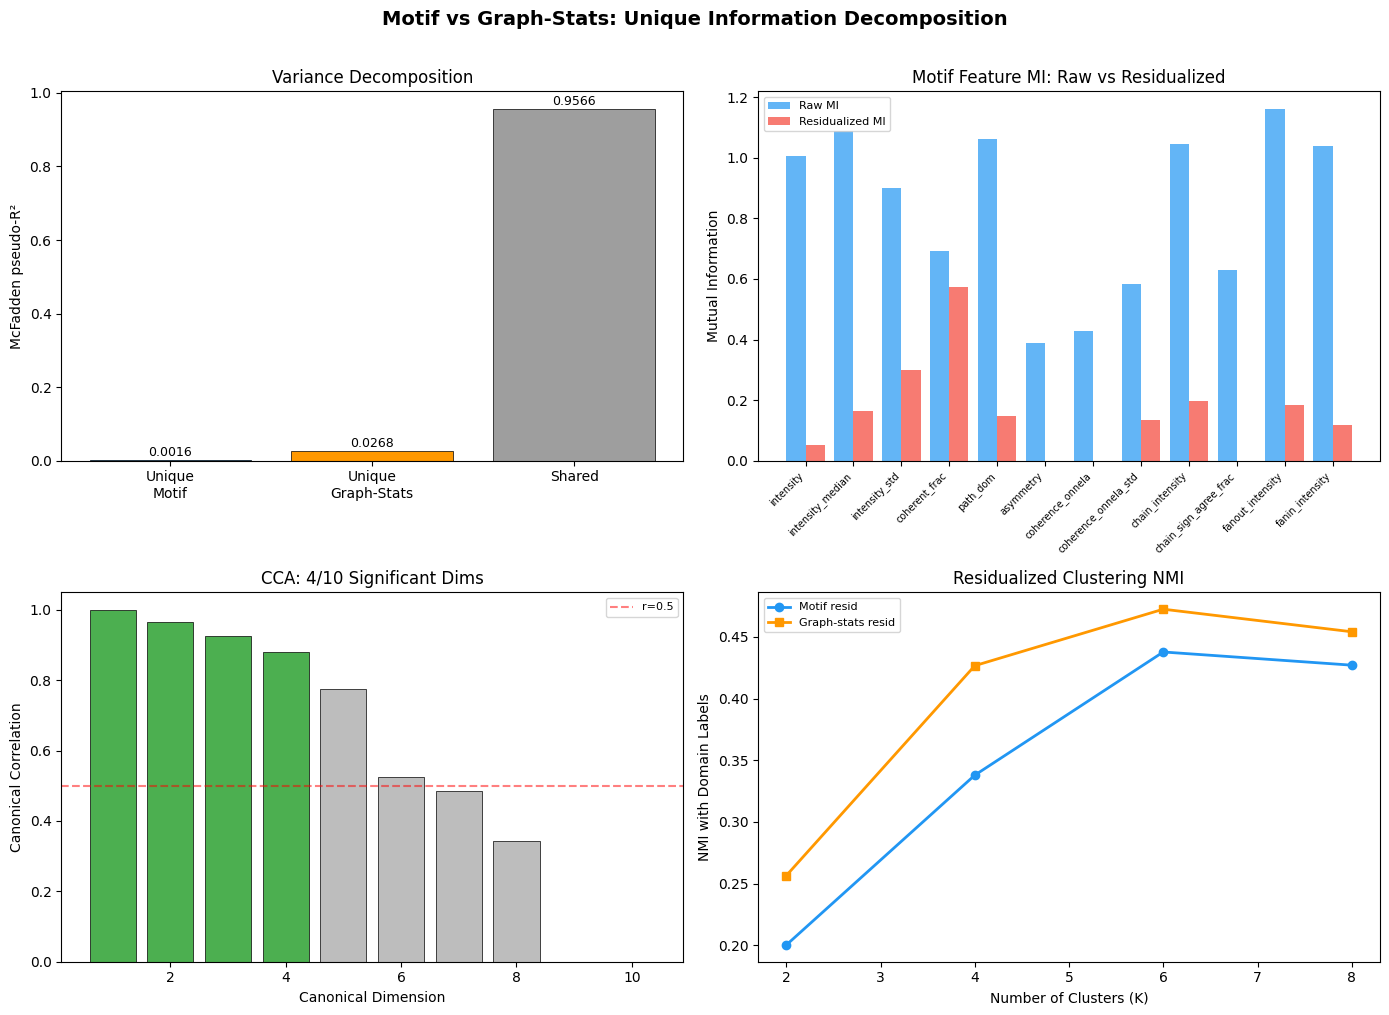

Figure saved to uid_results.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel 1: R² Variance Decomposition ---
ax = axes[0, 0]
components = ["Unique\nMotif", "Unique\nGraph-Stats", "Shared"]
values = [unique_motif, unique_gstat, shared]
colors = ["#2196F3", "#FF9800", "#9E9E9E"]
bars = ax.bar(components, values, color=colors, edgecolor="black", linewidth=0.5)
ax.set_ylabel("McFadden pseudo-R²")
ax.set_title("Variance Decomposition")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002, f"{val:.4f}", ha="center", va="bottom", fontsize=9)

# --- Panel 2: Per-Feature MI Retention (motif features only) ---
ax = axes[0, 1]
motif_feats = [f for f in per_feature if f["block"] == "motif" and f["raw_mi"] > 0.01]
if motif_feats:
    names = [f["name"].replace("ffl_", "").replace("_mean", "") for f in motif_feats]
    raw_vals = [f["raw_mi"] for f in motif_feats]
    resid_vals = [f["resid_mi"] for f in motif_feats]
    x_pos = np.arange(len(names))
    ax.bar(x_pos - 0.2, raw_vals, 0.4, label="Raw MI", color="#2196F3", alpha=0.7)
    ax.bar(x_pos + 0.2, resid_vals, 0.4, label="Residualized MI", color="#F44336", alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=7)
    ax.legend(fontsize=8)
ax.set_ylabel("Mutual Information")
ax.set_title("Motif Feature MI: Raw vs Residualized")

# --- Panel 3: Canonical Correlations ---
ax = axes[1, 0]
if canonical_corrs:
    dims = list(range(1, len(canonical_corrs) + 1))
    colors_cca = ["#4CAF50" if w["p"] < 0.05 else "#BDBDBD" for w in wilks_results]
    ax.bar(dims, canonical_corrs, color=colors_cca, edgecolor="black", linewidth=0.5)
    ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="r=0.5")
    ax.legend(fontsize=8)
ax.set_xlabel("Canonical Dimension")
ax.set_ylabel("Canonical Correlation")
ax.set_title(f"CCA: {n_significant}/{n_components} Significant Dims")

# --- Panel 4: Clustering NMI by K ---
ax = axes[1, 1]
k_vals = [int(k) for k in motif_resid_results["nmi_by_k"].keys()]
motif_nmis = [motif_resid_results["nmi_by_k"][str(k)] for k in k_vals]
gstat_nmis = [gstat_resid_results["nmi_by_k"][str(k)] for k in k_vals]
ax.plot(k_vals, motif_nmis, "o-", color="#2196F3", label="Motif resid", linewidth=2)
ax.plot(k_vals, gstat_nmis, "s-", color="#FF9800", label="Graph-stats resid", linewidth=2)
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("NMI with Domain Labels")
ax.set_title("Residualized Clustering NMI")
ax.legend(fontsize=8)

plt.suptitle("Motif vs Graph-Stats: Unique Information Decomposition", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("uid_results.png", dpi=100, bbox_inches="tight")
plt.show()
print("Figure saved to uid_results.png")